# Introduction

Welcome to the hands-on Colab notebook for TabPFN!

This install the online version of TabPFN using our web client. If you would like to access the offline version use: https://tinyurl.com/tabpfn-colab-local

**Installation**
* First, copy the notebook to be able to modify it.
* Then, run the cells in the installation block, this should
be good enough!

**API Registration**
* See the cell below to go through the registration process to use the pre-release TabPFN API for free.

---

> 🔵 **Hint** <br>
We recommend first enabling the **Table of Contents** with the `☰` icon in the top left and collapsing all sections by selecting all cells `Ctrl + Shift + A` and then pressing `Ctrl + ]`.

---

Thank you to [Lennart Purucker](https://github.com/LennartPurucker) for providing the original version of this notebook!

# Installation

The following cell installs a client that interacts with our pre-release API for the new version of TabPFN. This way, no GPU is required.

Restart your runtime and rerun the *cell*, if Colab asks for it.

In [1]:
# Install sklearn
!pip install scikit-learn==1.5.2

# Install TabPFN API Client
!pip install tabpfn-client

# TabPFN Extensions installs optional functionalities around the TabPFN model
# These include post-hoc ensembles, interpretability tools, and more
!git clone https://github.com/PriorLabs/tabpfn-extensions
!pip install -e tabpfn-extensions
!pip install tabpfn # TabPFN, currently required by tabpfn-extensions, but not basic usage


# Install Baselines
!pip install catboost xgboost

# Install example datasets
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 66.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.3 MB/s eta 0:00:00
Cloning into 'tabpfn-extensions'...
remote: Enumerating objects: 2089, done.
remote: Counting objects: 100% (288/288), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 2089 (delta 209), reused 175 (delta 175), pack-reused 1801 (from 2)
Receiving objects: 100% (2089/2089), 775.16 KiB | 2.27 MiB/s, done.
Resolving deltas: 100% (1273/1273), done.
Obtaining file:///content/tabpfn-extensions
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.

**Now Restart the Runtime**

# Necessary Imports for the Notebook

The examples in this notebook require the following imports.
Make sure to run this cell before any other cell.




In [2]:
pip install skfeature-chappers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 3.2 MB/s eta 0:00:00


In [3]:
pip install nanopq

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nanopq import PQ  # Make sure you have nanopq installed: pip install nanopq
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from skfeature.function.information_theoretical_based import CMIM, JMI
import gc
import time
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from tabpfn import TabPFNClassifier

C:\Users\User\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\User\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\User\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
import scipy.spatial as ss
from scipy.special import digamma
from math import log
import numpy.random as nr
import numpy as np
import random
def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

In [3]:
import numpy as np
from math import log

def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

def fast_cmim(X, y, **kwargs):
    """
    This function implements the CMIM feature selection.
    Input
    -----
    X: {numpy array}, shape (n_samples, n_features)
        Input data, guaranteed to be a discrete numpy array
    y: {numpy array}, shape (n_samples,)
        guaranteed to be a numpy array
    kwargs: {dictionary}
        n_selected_features: {int}
            number of features to select
    Output
    ------
    F: {numpy array}, shape (n_features,)
        index of selected features, F[0] is the most important feature
    t1: {numpy array}, shape: (n_features,)
        minimal corresponding mutual information between selected features and response when
        conditionned on a previously selected feature
    Reference
    ---------
    Fleuret 2004 - Fast Binary Feature Selection with Conditional Mutual Information
    http://www.idiap.ch/~fleuret/papers/fleuret-jmlr2004.pdf
    """

    n_samples, n_features = X.shape
    is_n_selected_features_specified = False

    if 'n_selected_features' in kwargs.keys():
        n_selected_features = kwargs['n_selected_features']
        is_n_selected_features_specified = True
        F = np.nan * np.zeros(n_selected_features)
    else:
        F = np.nan * np.zeros(n_features)

    # t1
    t1 = np.zeros(n_features)

    # m is a counting indicator
    m = np.zeros(n_features) - 1

    for i in range(n_features):
        f = X[:, i]
        t1[i] = midd(f, y)


    for k in range(n_features):
        ### uncomment to keep track
        # counter = int(np.sum(~np.isnan(F)))
        # if counter%5 == 0 or counter <= 1:
        #     print("F contains %s features"%(counter))
        if k == 0:
            # select the feature whose mutual information is the largest
            idx = np.argmax(t1)
            F[0] = idx
            f_select = X[:, idx]

        if is_n_selected_features_specified:
            if np.sum(~np.isnan(F)) == n_selected_features:
                break

        sstar = -1000000 # start with really low value for best partial score sstar
        for i in range(n_features):

            if i not in F:

                while (t1[i] > sstar) and (m[i]<k-1) :
                    m[i] = m[i] + 1
                    t1[i] = min(t1[i], cmidd(X[:,i], # feature i
                                             y,  # target
                                             X[:, int(F[int(m[i])])] # conditionned on selected features
                                            )
                               )
                if t1[i] > sstar:
                    sstar = t1[i]
                    F[k+1] = i

    F = np.array(F[F>-100])
    F = F.astype(int)
    t1 = t1[F]
    return (F, t1)

# **Reading CSV file**

In [10]:
# Lx`oad data
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-Malgenome.csv")
#data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-CIC-2020.csv")
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)

In [ ]:
data

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED,Class
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1
4,1,1,1,1,1,1,1,1,1,1,...,1,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1
5074,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,1,0,0,0,0,1
5075,0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
5076,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

In [ ]:
# record start time
start = time.time()
f, t = fast_cmim(X_train,y_train, n_selected_features = 100)
end = time.time()

# print the difference between start
# and end time in milli. secs
print("The time of execution of above program is :",
      (end-start), "sec")

The time of execution of above program is : 43.678600788116455 sec


In [ ]:
f

array([  0,   2,  13,   8,   5,  11,  20,  15,  35,   9,  10,  21,  16,
        12,  36,  18,  24,  42,  28,  39,  14,  44,  31,  23,  19,  51,
        32,   4,  33,  22,  30,  34,  27,  62,  45,  29,  59,  68,  66,
        50,  26,  78,  47,  65,  99,  57,  60,  71, 113,  54,  49,  46,
        17,  37,  93,  76,  77,  84, 125,   7,  75,  89,  72,  25,  86,
        55, 114, 119, 108,  87,  38, 135, 129,  91,  95,  63,  80,  53,
       100,  64,  94,   1, 110,  79,  88, 111,  40,  43, 124,  48,  90,
       126, 142, 120, 147, 106,  67,  85, 148, 134])

In [7]:
f = [0,   2,  13,   8,   5,  11,  20,  15,  35,   9,  10,  21,  16,
        12,  36,  18,  24,  42,  28,  39,  14,  44,  31,  23,  19,  51,
        32,   4,  33,  22,  30,  34,  27,  62,  45,  29,  59,  68,  66,
        50,  26,  78,  47,  65,  99,  57,  60,  71, 113,  54,  49,  46,
        17,  37,  93,  76,  77,  84, 125,   7,  75,  89,  72,  25,  86,
        55, 114, 119, 108,  87,  38, 135, 129,  91,  95,  63,  80,  53,
       100,  64,  94,   1, 110,  79,  88, 111,  40,  43, 124,  48,  90,
       126, 142, 120, 147, 106,  67,  85, 148, 134]

In [8]:
f = np.array(f)
f

array([  0,   2,  13,   8,   5,  11,  20,  15,  35,   9,  10,  21,  16,
        12,  36,  18,  24,  42,  28,  39,  14,  44,  31,  23,  19,  51,
        32,   4,  33,  22,  30,  34,  27,  62,  45,  29,  59,  68,  66,
        50,  26,  78,  47,  65,  99,  57,  60,  71, 113,  54,  49,  46,
        17,  37,  93,  76,  77,  84, 125,   7,  75,  89,  72,  25,  86,
        55, 114, 119, 108,  87,  38, 135, 129,  91,  95,  63,  80,  53,
       100,  64,  94,   1, 110,  79,  88, 111,  40,  43, 124,  48,  90,
       126, 142, 120, 147, 106,  67,  85, 148, 134])

In [11]:
selected_features_names=[]
for i in range(len(f)):
    selected_features_names.append(data.columns[f[i]])
selected_features_names

['transact',
 'onServiceConnected',
 'READ_PHONE_STATE',
 'TelephonyManager.getSubscriberId',
 'READ_SMS',
 'android.intent.action.BOOT_COMPLETED',
 'chmod',
 'GET_ACCOUNTS',
 'android.telephony.gsm.SmsManager',
 'Ljava.lang.Class.getCanonicalName',
 'Ljava.lang.Class.getMethods',
 'createSubprocess',
 'SEND_SMS',
 'Ljava.lang.Class.getField',
 '.system.bin',
 'getBinder',
 'TelephonyManager.getDeviceId',
 'CAMERA',
 'Ljava.lang.Class.getPackage',
 'INSTALL_PACKAGES',
 'Landroid.content.Context.unregisterReceiver',
 'android.intent.action.SEND',
 'TelephonyManager.getLine1Number',
 'WRITE_APN_SETTINGS',
 'Ljava.lang.Class.cast',
 'ACCESS_LOCATION_EXTRA_COMMANDS',
 'getCallingUid',
 'android.os.Binder',
 'USE_CREDENTIALS',
 'Ljava.net.URLDecoder',
 'ClassLoader',
 'MANAGE_ACCOUNTS',
 'HttpGet.init',
 'android.intent.action.TIME_SET',
 'onBind',
 'abortBroadcast',
 '.system.app',
 'SYSTEM_ALERT_WINDOW',
 'BLUETOOTH',
 'PackageInstaller',
 'Ljava.lang.Class.getDeclaredField',
 'READ_CALEN

In [12]:
len(selected_features_names)

100

# find the highest accuracy with respect to different number of features

In [ ]:
from tabpfn import TabPFNClassifier

tab_pfn_={
    "acc":{"index":[],"val":[],},
    "per":{"index":[],"val":[],},
    "rec":{"index":[],"val":[],},
    "f1s":{"index":[],"val":[],},
    "auc":{"index":[],"val":[],},
}

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-Malgenome.csv")
for i in range(2,len(selected_features_names)+1,2):
    X = data[selected_features_names[:i]].values  # Features
    y = data.iloc[:, -1].values   # Binary labels (0 or 1)
    start = time.time()
    pq_pq = PQ(M=int(i/2), Ks=2)
    pq_pq.fit(X.astype(np.float32))
    codes_pq = pq_pq.encode(X.astype(np.float32))
    end = time.time()

    # print the difference between start
    # and end time in milli. secs
    print("The time of execution of above program is :",
          (end-start), "sec")
    X_train, X_test, y_train, y_test = train_test_split(codes_pq,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
    # Initialize a classifier
    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")
    tab_pfn_["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_["acc"]['index'].append(i)
    tab_pfn_["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_["per"]['index'].append(i)
    tab_pfn_["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_["rec"]['index'].append(i)
    tab_pfn_["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_["f1s"]['index'].append(i)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_["auc"]['index'].append(i)

M: 1, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 1
Encoding the subspace: 0 / 1
The time of execution of above program is : 0.016923904418945312 sec
The time of execution of training the tabpfn is : 106.96992087364197 sec
The time of execution of testing sample with the tabpfn is : 0.0005360029813811535 sec
M: 2, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 2
Training the subspace: 1 / 2
Encoding the subspace: 0 / 2
Encoding the subspace: 1 / 2
The time of execution of above program is : 0.007861614227294922 sec
The time of execution of training the tabpfn is : 40.05312132835388 sec
The time of execution of testing sample with the tabpfn is : 0.0006442729413040041 sec
M: 3, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 3
Training the subspace: 1 / 3
Training the subspace: 2 / 3
Encoding the subspace: 0 / 3
Encoding the 

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


The time of execution of training the tabpfn is : 14.30403184890747 sec
The time of execution of testing sample with the tabpfn is : 0.000832345776670561 sec
M: 6, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 6
Training the subspace: 1 / 6
Training the subspace: 2 / 6
Training the subspace: 3 / 6
Training the subspace: 4 / 6
Training the subspace: 5 / 6
Encoding the subspace: 0 / 6
Encoding the subspace: 1 / 6
Encoding the subspace: 2 / 6
Encoding the subspace: 3 / 6
Encoding the subspace: 4 / 6
Encoding the subspace: 5 / 6
The time of execution of above program is : 0.02240610122680664 sec


/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


The time of execution of training the tabpfn is : 11.786119222640991 sec
The time of execution of testing sample with the tabpfn is : 0.0009389270947674128 sec
M: 7, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 7
Training the subspace: 1 / 7
Training the subspace: 2 / 7
Training the subspace: 3 / 7
Training the subspace: 4 / 7
Training the subspace: 5 / 7
Training the subspace: 6 / 7
Encoding the subspace: 0 / 7
Encoding the subspace: 1 / 7
Encoding the subspace: 2 / 7
Encoding the subspace: 3 / 7
Encoding the subspace: 4 / 7
Encoding the subspace: 5 / 7
Encoding the subspace: 6 / 7
The time of execution of above program is : 0.026493310928344727 sec


...

The time of execution of training the tabpfn is : 1.5559520721435547 sec
The time of execution of testing sample with the tabpfn is : 0.00466252922073124 sec
M: 49, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 49
Training the subspace: 1 / 49
Training the subspace: 2 / 49
Training the subspace: 3 / 49
Training the subspace: 4 / 49
Training the subspace: 5 / 49
Training the subspace: 6 / 49
Training the subspace: 7 / 49
Training the subspace: 8 / 49
Training the subspace: 9 / 49
Training the subspace: 10 / 49
Training the subspace: 11 / 49
Training the subspace: 12 / 49
Training the subspace: 13 / 49
Training the subspace: 14 / 49
Training the subspace: 15 / 49
Training the subspace: 16 / 49
Training the subspace: 17 / 49
Training the subspace: 18 / 49
Training the subspace: 19 / 49
Training the subspace: 20 / 49
Training the subspace: 21 / 49
Training the subspace: 22 / 49
Training the subspace: 23 / 49
Training the subspace: 24 /

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


The time of execution of training the tabpfn is : 1.461271047592163 sec
The time of execution of testing sample with the tabpfn is : 0.004690993019915003 sec
M: 50, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 50
Training the subspace: 1 / 50
Training the subspace: 2 / 50
Training the subspace: 3 / 50
Training the subspace: 4 / 50
Training the subspace: 5 / 50
Training the subspace: 6 / 50
Training the subspace: 7 / 50
Training the subspace: 8 / 50
Training the subspace: 9 / 50
Training the subspace: 10 / 50
Training the subspace: 11 / 50
Training the subspace: 12 / 50
Training the subspace: 13 / 50
Training the subspace: 14 / 50
Training the subspace: 15 / 50
Training the subspace: 16 / 50
Training the subspace: 17 / 50
Training the subspace: 18 / 50
Training the subspace: 19 / 50
Training the subspace: 20 / 50
Training the subspace: 21 / 50
Training the subspace: 22 / 50
Training the subspace: 23 / 50
Training the subspace: 24 /

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


The time of execution of training the tabpfn is : 1.4159045219421387 sec
The time of execution of testing sample with the tabpfn is : 0.004820106067056731 sec


In [ ]:
print("the highest accuracy where the number of features is: ", tab_pfn_["acc"]['index'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest accuracy value is: ", tab_pfn_["acc"]['val'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest AUC where the number of features is: ", tab_pfn_["auc"]['index'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest AUC value is: ", tab_pfn_["auc"]['val'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest precision where the number of features is: ", tab_pfn_["per"]['index'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest precision value is: ", tab_pfn_["per"]['val'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest recall where the number of features is: ", tab_pfn_["rec"]['index'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest recall value is: ", tab_pfn_["rec"]['val'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest f1_score where the number of features is: ", tab_pfn_["f1s"]['index'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])
print("the highest f1_score value is: ", tab_pfn_["f1s"]['val'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])

the highest accuracy where the number of features is:  88
the highest accuracy value is:  0.9931102362204725
the highest AUC where the number of features is:  76
the highest AUC value is:  0.9992224704112181
the highest precision where the number of features is:  88
the highest precision value is:  0.9942418426103646
the highest recall where the number of features is:  84
the highest recall value is:  0.9923371647509579
the highest f1_score where the number of features is:  88
the highest f1_score value is:  0.9932885906040269


In [ ]:
tab_pfn_["auc"]['val'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))]

np.float64(0.9990111219693797)

In [ ]:
tab_pfn_['acc']['val'][43] #88 features

0.9931102362204725

In [ ]:
tab_pfn_['acc']['val'][37] #76 features

0.9891732283464567

In [ ]:
tab_pfn_['auc']['val'][43] #88 features

np.float64(0.9990111219693797)

In [ ]:
tab_pfn_['auc']['val'][37] #76 features

np.float64(0.9992224704112181)

In [ ]:
tab_pfn_['per']['val'][43] #88 features

np.float64(0.9942418426103646)

In [ ]:
tab_pfn_['per']['val'][37] #76 features

np.float64(0.9904030710172744)

In [ ]:
tab_pfn_['rec']['val'][43] #88 features

np.float64(0.9923371647509579)

In [ ]:
tab_pfn_['rec']['val'][37] #76 features

np.float64(0.9885057471264368)

In [ ]:
tab_pfn_['f1s']['val'][43] #88 features

np.float64(0.9932885906040269)

In [ ]:
tab_pfn_['f1s']['val'][37] #76 features

np.float64(0.9894534995206136)

In [ ]:
tab_pfn_

{'acc': {'index': [2,
   4,
   6,
   8,
   10,
   12,
   14,
   16,
   18,
   20,
   22,
   24,
   26,
   28,
   30,
   32,
   34,
   36,
   38,
   40,
   42,
   44,
   46,
   48,
   50,
   52,
   54,
   56,
   58,
   60,
   62,
   64,
   66,
   68,
   70,
   72,
   74,
   76,
   78,
   80,
   82,
   84,
   86,
   88,
   90,
   92,
   94,
   96,
   98,
   100],
  'val': [0.8179133858267716,
   0.8061023622047244,
   0.8297244094488189,
   0.9271653543307087,
   0.937992125984252,
   0.9409448818897638,
   0.9389763779527559,
   0.9429133858267716,
   0.9478346456692913,
   0.9557086614173228,
   0.9547244094488189,
   0.9566929133858267,
   0.9616141732283464,
   0.9665354330708661,
   0.9704724409448819,
   0.9753937007874016,
   0.9734251968503937,
   0.9783464566929134,
   0.9812992125984252,
   0.9803149606299213,
   0.9793307086614174,
   0.9812992125984252,
   0.9812992125984252,
   0.9832677165354331,
   0.9832677165354331,
   0.9832677165354331,
   0.9901574803149606,
   0.9881

In [ ]:
tab_pfn_['acc']['val']

[0.8179133858267716,
 0.8061023622047244,
 0.8297244094488189,
 0.9271653543307087,
 0.937992125984252,
 0.9409448818897638,
 0.9389763779527559,
 0.9429133858267716,
 0.9478346456692913,
 0.9557086614173228,
 0.9547244094488189,
 0.9566929133858267,
 0.9616141732283464,
 0.9665354330708661,
 0.9704724409448819,
 0.9753937007874016,
 0.9734251968503937,
 0.9783464566929134,
 0.9812992125984252,
 0.9803149606299213,
 0.9793307086614174,
 0.9812992125984252,
 0.9812992125984252,
 0.9832677165354331,
 0.9832677165354331,
 0.9832677165354331,
 0.9901574803149606,
 0.9881889763779528,
 0.9891732283464567,
 0.9881889763779528,
 0.9901574803149606,
 0.9872047244094488,
 0.9901574803149606,
 0.9891732283464567,
 0.9891732283464567,
 0.9881889763779528,
 0.9862204724409449,
 0.9891732283464567,
 0.9901574803149606,
 0.9891732283464567,
 0.9911417322834646,
 0.9921259842519685,
 0.9901574803149606,
 0.9931102362204725,
 0.9891732283464567,
 0.9881889763779528,
 0.9891732283464567,
 0.98917322834

In [ ]:
tab_pfn_["rec"]['val']

[np.float64(0.9521072796934866),
 np.float64(0.6360153256704981),
 np.float64(0.7049808429118773),
 np.float64(0.8984674329501916),
 np.float64(0.9137931034482759),
 np.float64(0.9118773946360154),
 np.float64(0.9482758620689655),
 np.float64(0.9386973180076629),
 np.float64(0.921455938697318),
 np.float64(0.9540229885057471),
 np.float64(0.9521072796934866),
 np.float64(0.9559386973180076),
 np.float64(0.9597701149425287),
 np.float64(0.9597701149425287),
 np.float64(0.9674329501915708),
 np.float64(0.975095785440613),
 np.float64(0.9636015325670498),
 np.float64(0.975095785440613),
 np.float64(0.9789272030651341),
 np.float64(0.975095785440613),
 np.float64(0.9808429118773946),
 np.float64(0.9770114942528736),
 np.float64(0.9770114942528736),
 np.float64(0.9789272030651341),
 np.float64(0.9789272030651341),
 np.float64(0.9885057471264368),
 np.float64(0.9904214559386973),
 np.float64(0.9885057471264368),
 np.float64(0.9904214559386973),
 np.float64(0.9865900383141762),
 np.float64(0.

# find the average accuracy with respect to the best accuracy gained by 88 features

In [13]:
from tabpfn import TabPFNClassifier
import tracemalloc

tab_pfn_max={
    "acc":{"fold":[],"val":[],},
    "per":{"fold":[],"val":[],},
    "rec":{"fold":[],"val":[],},
    "f1s":{"fold":[],"val":[],},
    "auc":{"fold":[],"val":[],},
}
memory = {
    "current":[],
    "peak":[]
}

train_time=[]
test_time=[]

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-Malgenome.csv")
X = data[selected_features_names[:88]].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
start = time.time()
pq_pq = PQ(M=int(88/2), Ks=2)
pq_pq.fit(X.astype(np.float32))
codes_pq = pq_pq.encode(X.astype(np.float32))
end = time.time()

kf = KFold(n_splits=5, random_state=2, shuffle=True)
for q, (train_index, test_index) in enumerate(kf.split(codes_pq)):
    print(f"Fold {q+1}:")
    print("The time of execution of Fold " ,q+1, " is :", (end-start), "sec")

    X_train = codes_pq[train_index]
    y_train = data["Class"].iloc[train_index].values
    X_test = codes_pq[test_index]
    y_test = data["Class"].iloc[test_index].values

    tracemalloc.start()

    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    train_time.append(end-start)
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    test_time.append((end-start)/len(X_test))

    c, p = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory["current"].append(c)
    memory['peak'].append(p)

    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")

    tab_pfn_max["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_max["acc"]['fold'].append(q+1)
    tab_pfn_max["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_max["per"]['fold'].append(q+1)
    tab_pfn_max["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_max["rec"]['fold'].append(q+1)
    tab_pfn_max["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_max["f1s"]['fold'].append(q+1)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_max["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_max["auc"]['fold'].append(q+1)


M: 44, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 44
Training the subspace: 1 / 44
Training the subspace: 2 / 44
Training the subspace: 3 / 44
Training the subspace: 4 / 44
Training the subspace: 5 / 44
Training the subspace: 6 / 44
Training the subspace: 7 / 44
Training the subspace: 8 / 44
Training the subspace: 9 / 44
Training the subspace: 10 / 44
Training the subspace: 11 / 44
Training the subspace: 12 / 44
Training the subspace: 13 / 44
Training the subspace: 14 / 44
Training the subspace: 15 / 44
Training the subspace: 16 / 44
Training the subspace: 17 / 44
Training the subspace: 18 / 44
Training the subspace: 19 / 44
Training the subspace: 20 / 44
Training the subspace: 21 / 44
Training the subspace: 22 / 44


/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 23 / 44
Training the subspace: 24 / 44
Training the subspace: 25 / 44
Training the subspace: 26 / 44
Training the subspace: 27 / 44
Training the subspace: 28 / 44
Training the subspace: 29 / 44
Training the subspace: 30 / 44
Training the subspace: 31 / 44
Training the subspace: 32 / 44
Training the subspace: 33 / 44
Training the subspace: 34 / 44
Training the subspace: 35 / 44
Training the subspace: 36 / 44
Training the subspace: 37 / 44
Training the subspace: 38 / 44
Training the subspace: 39 / 44
Training the subspace: 40 / 44
Training the subspace: 41 / 44
Training the subspace: 42 / 44
Training the subspace: 43 / 44
Encoding the subspace: 0 / 44
Encoding the subspace: 1 / 44
Encoding the subspace: 2 / 44
Encoding the subspace: 3 / 44
Encoding the subspace: 4 / 44
Encoding the subspace: 5 / 44
Encoding the subspace: 6 / 44
Encoding the subspace: 7 / 44
Encoding the subspace: 8 / 44
Encoding the subspace: 9 / 44
Encoding the subspace: 10 / 44
Encoding the subsp

/usr/local/lib/python3.11/dist-packages/tabpfn/base.py:89: UserWarning: Downloading model to /root/.cache/tabpfn/tabpfn-v2-classifier.ckpt.
  model, _, config_ = load_model_criterion_config(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v2-classifier.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

The time of execution of training the tabpfn is : 11.017553091049194 sec
The time of execution of testing sample with the tabpfn is : 0.015809513687148807 sec
Fold 2:
The time of execution of Fold  2  is : 16.06246590614319 sec
The time of execution of training the tabpfn is : 6.308347463607788 sec
The time of execution of testing sample with the tabpfn is : 0.00402203906239487 sec
Fold 3:
The time of execution of Fold  3  is : 4.0863916873931885 sec
The time of execution of training the tabpfn is : 5.9032886028289795 sec
The time of execution of testing sample with the tabpfn is : 0.004050290725362582 sec
Fold 4:
The time of execution of Fold  4  is : 4.115095376968384 sec
The time of execution of training the tabpfn is : 5.590855121612549 sec
The time of execution of testing sample with the tabpfn is : 0.004110955487331146 sec
Fold 5:
The time of execution of Fold  5  is : 4.172619819641113 sec
The time of execution of training the tabpfn is : 5.770662307739258 sec
The time of execut

In [14]:
tab_pfn_max

{'acc': {'fold': [1, 2, 3, 4, 5],
  'val': [0.9931102362204725,
   0.9872047244094488,
   0.985236220472441,
   0.9783251231527094,
   0.987192118226601]},
 'per': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9942418426103646),
   np.float64(0.9941747572815534),
   np.float64(0.9938398357289527),
   np.float64(0.9877551020408163),
   np.float64(0.9899193548387096)]},
 'rec': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9923371647509579),
   np.float64(0.9808429118773946),
   np.float64(0.9758064516129032),
   np.float64(0.968),
   np.float64(0.9839679358717435)]},
 'f1s': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9932885906040269),
   np.float64(0.9874638379942141),
   np.float64(0.9847405900305188),
   np.float64(0.9777777777777777),
   np.float64(0.9869346733668342)]},
 'auc': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9990305117346859),
   np.float64(0.9979136612530443),
   np.float64(0.9979896867245657),
   np.float64(0.9969495145631068),
   np.float64(0.999054

In [15]:
print(f"Current memory usage: {np.average(memory['current']) / 1024 / 1024:.1f} MB")
print(f"Peak usage: {np.average(memory['peak']) / 1024 / 1024:.1f} MB")

Current memory usage: 14.8 MB
Peak usage: 21.6 MB


In [16]:
print("The time of execution of training the tabpfn is :",np.average(train_time), "sec")
print("The time of execution of testing the tabpfn is :",np.average(test_time), "sec")

The time of execution of training the tabpfn is : 6.918141317367554 sec
The time of execution of testing the tabpfn is : 0.006444399804946159 sec


In [17]:
np.average(tab_pfn_max["acc"]["val"])

np.float64(0.9862136844963345)

In [18]:
np.average(tab_pfn_max["auc"]["val"])

np.float64(0.9981875368892263)

In [19]:
np.average(tab_pfn_max["per"]["val"])

np.float64(0.9919861785000792)

In [20]:
np.average(tab_pfn_max["rec"]["val"])

np.float64(0.9801908928225999)

In [21]:
np.average(tab_pfn_max["f1s"]["val"])

np.float64(0.9860410939546744)

In [ ]:
accuracy_tabPFN = pd.DataFrame(tab_pfn_['acc']['val'], index=tab_pfn_['acc']['index'])
Precision_tabPFN = pd.DataFrame(tab_pfn_['per']['val'], index=tab_pfn_['per']['index'])
Recall_tabPFN = pd.DataFrame(tab_pfn_['rec']['val'], index=tab_pfn_['rec']['index'])
f1Score_tabPFN = pd.DataFrame(tab_pfn_['f1s']['val'], index=tab_pfn_['f1s']['index'])
auc_tabPFN = pd.DataFrame(tab_pfn_['auc']['val'], index=tab_pfn_['auc']['index'])

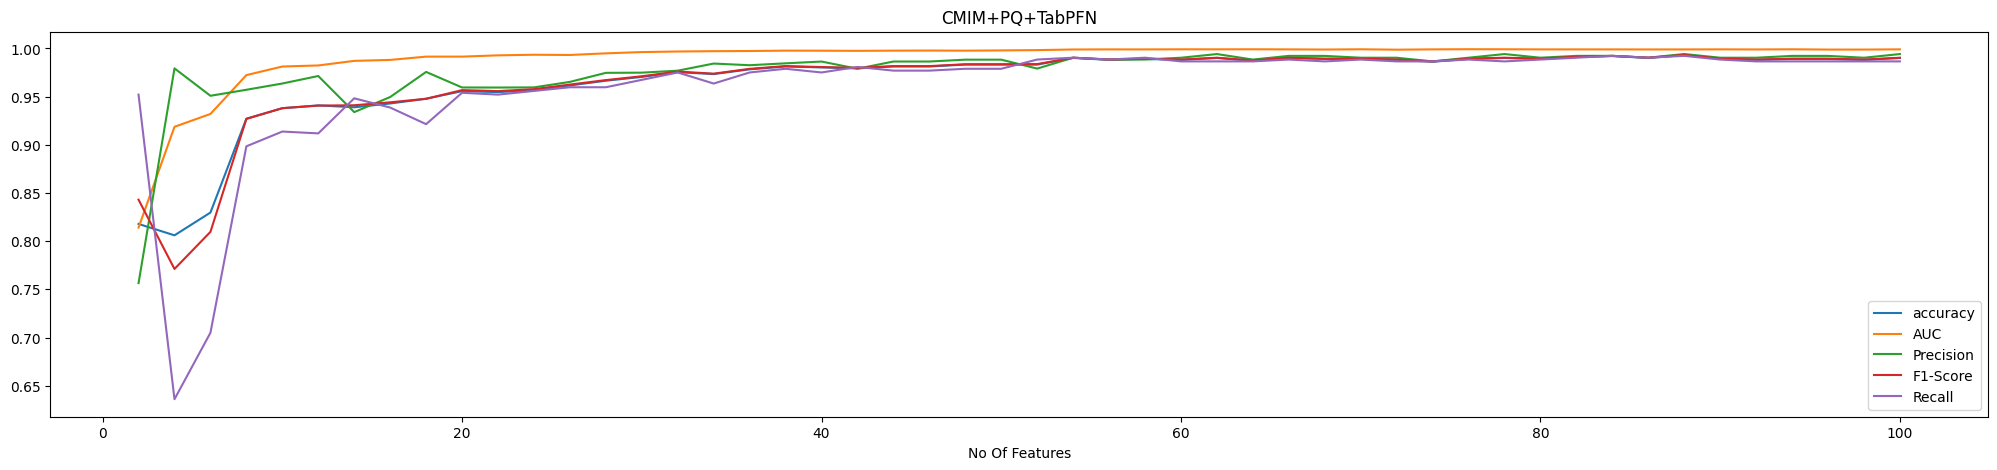

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")
plt.plot(auc_tabPFN, label="AUC")
plt.plot(Precision_tabPFN, label="Precision")
plt.plot(f1Score_tabPFN, label="F1-Score")
plt.plot(Recall_tabPFN , label="Recall")

plt.title("CMIM+PQ+TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("")
plt.legend()
plt.show()

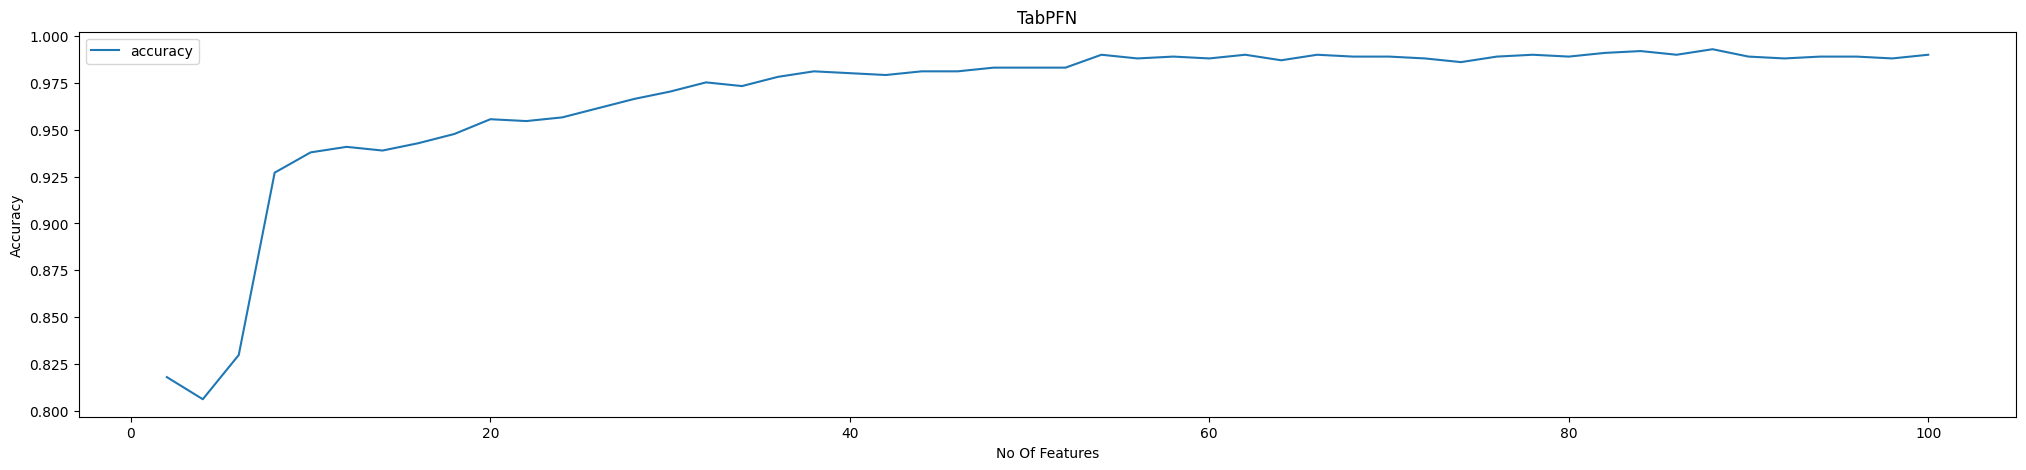

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

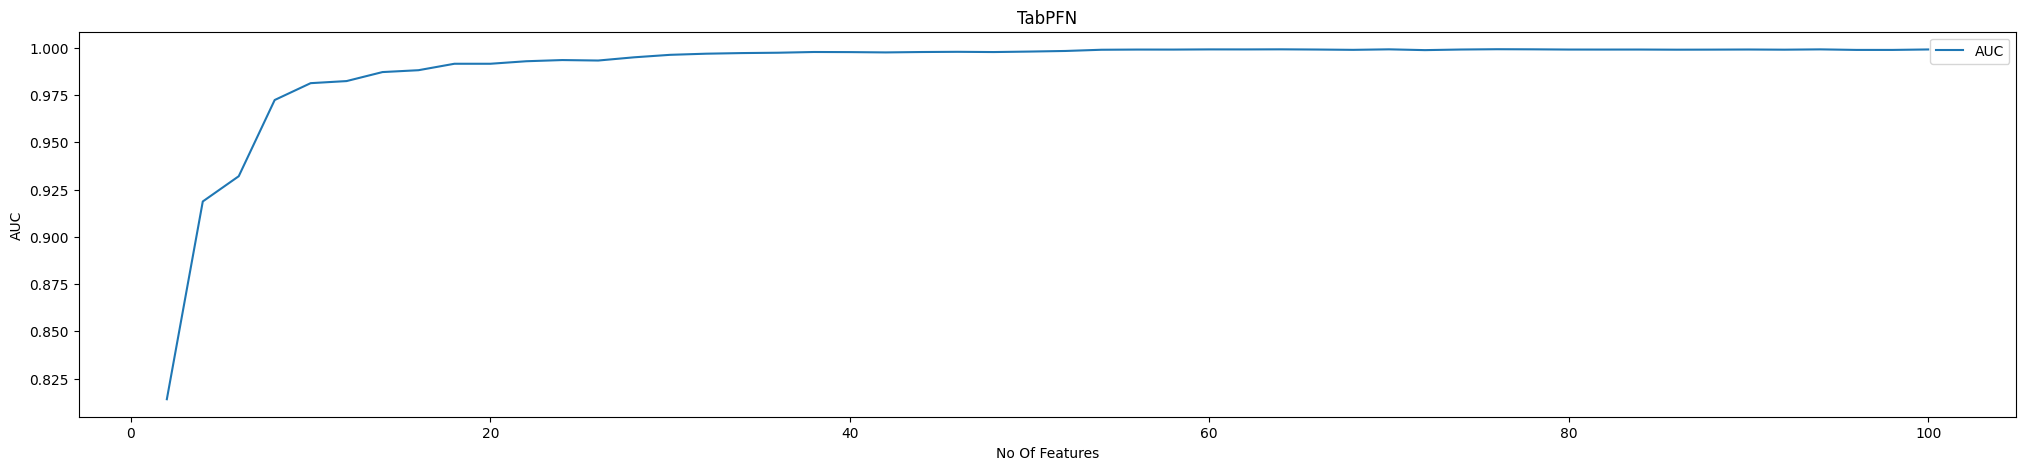

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(auc_tabPFN, label="AUC")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("AUC")
plt.legend()
plt.show()

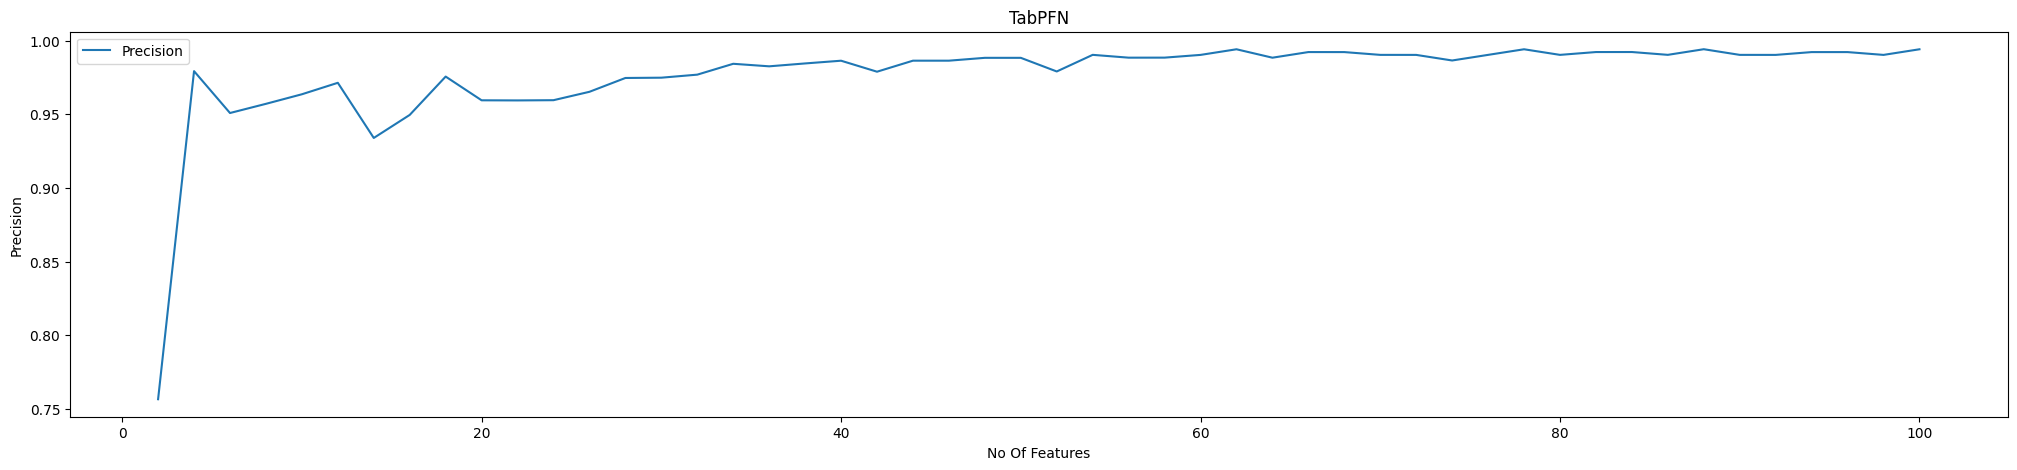

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Precision_tabPFN, label="Precision")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Precision")
plt.legend()
plt.show()

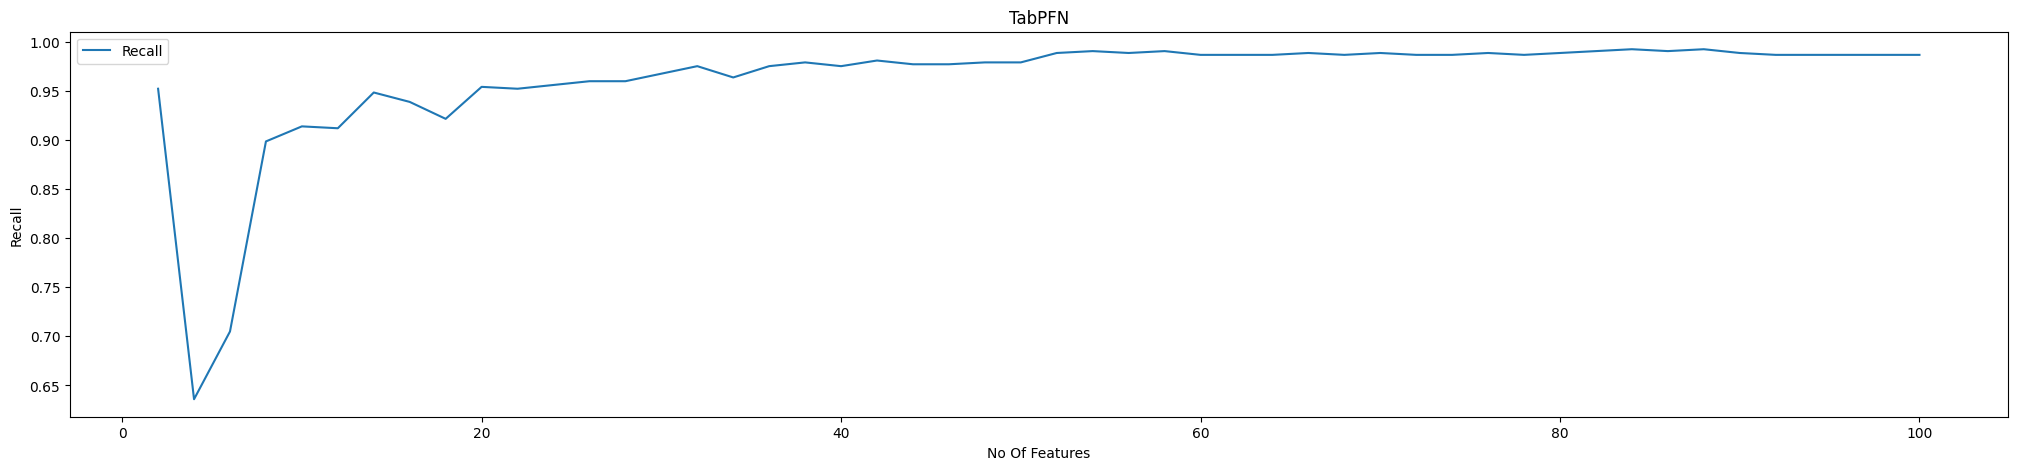

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Recall_tabPFN , label="Recall")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Recall")
plt.legend()
plt.show()

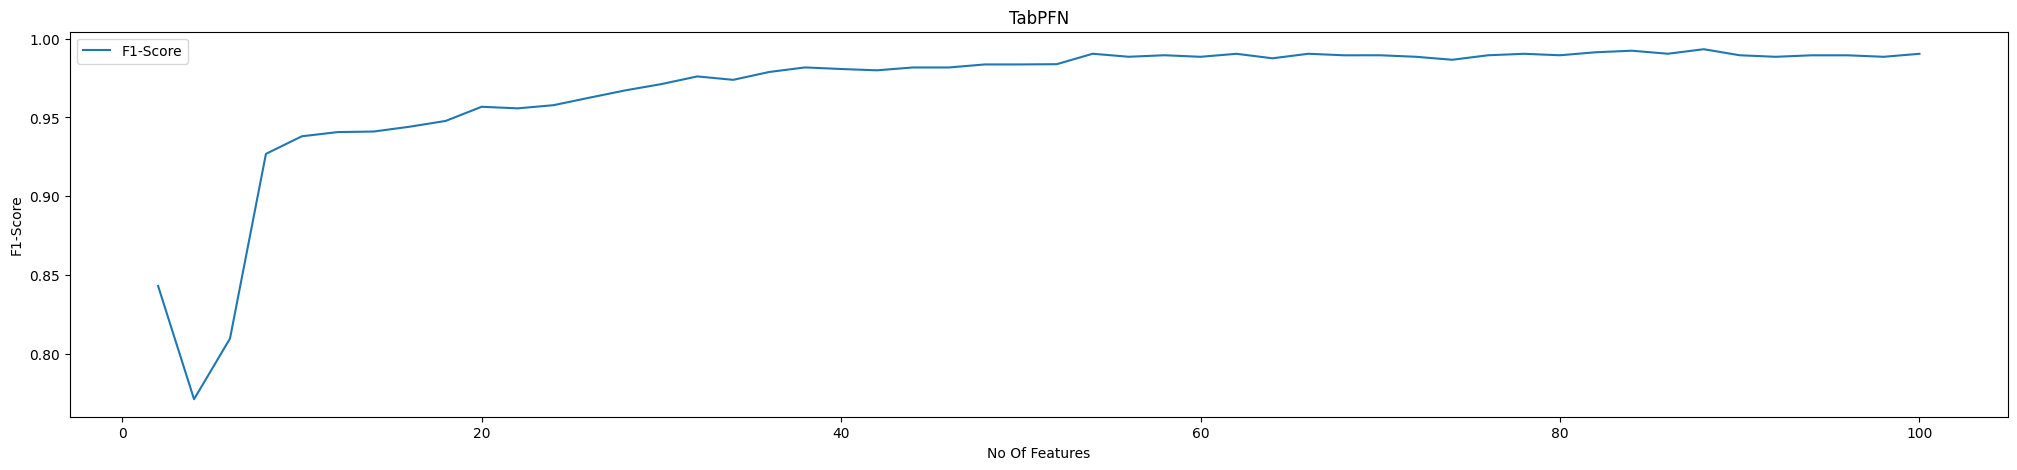

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(f1Score_tabPFN, label="F1-Score")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("F1-Score")
plt.legend()
plt.show()

# test the tabpfn with the total 100 **features**

In [ ]:
from tabpfn import TabPFNClassifier
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-Drebin.csv")
X = data[selected_features_names].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
# Initialize a classifier
clf = TabPFNClassifier()
start = time.time()
clf.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the tabpfn is :", (end-start), "sec")
# Predict labels
start = time.time()
y_pred = clf.predict(X_test)
end = time.time()
print("The time of execution of testing sample with the tabpfn is :", ((end-start)/len(X_test)), "sec")
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
y_prob = clf.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
print("AUC: ", auc(fpr, tpr))

The time of execution of training the tabpfn is : 8.224750280380249 sec
The time of execution of testing sample with the tabpfn is : 0.004008741733235364 sec
Accuracy_score:  0.9922861150070126
Precision_score:  1.0
Recall_score  0.9846368715083799
F1_score:  0.9922589725545391
AUC:  0.9992554488944841


In [ ]:
#SVM
X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)  # `probability=True` for AUC calculation

start = time.time()
svm_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the SVM is :",
          (end-start), "sec")

start = time.time()
y_pred = svm_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the SVM is :",
          ((end-start)/len(X_test)), "sec")

y_prob = svm_model.predict_proba(X_test)[:, 1]  # Get probability scores for ROC curve

# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the SVM is : 1.9641799926757812 sec
The time of execution of testing a sample of the SVM is : 0.00016676276128054667 sec
Accuracy_score:  0.9929873772791024
Precision_score:  1.0
Recall_score  0.9860335195530726
F1_score:  0.9929676511954993
AUC:  0.9979669918955072


In [ ]:
#Random forest
X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)
start = time.time()
rf_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the RandomForest is :", (end-start), "sec")


# Make predictions on the test set
start = time.time()
y_pred = rf_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the RandomForest is :", ((end-start)/len(X_test)), "sec")

# Get probability estimates for the positive class (needed for ROC curve)
y_prob = rf_model.predict_proba(X_test)[:, 1]
# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the RandomForest is : 0.5930635929107666 sec
The time of execution of testing a sample of the RandomForest is : 1.7891759457795516e-05 sec
Accuracy_score:  0.9936886395511921
Precision_score:  1.0
Recall_score  0.9874301675977654
F1_score:  0.9936753338018272
AUC:  0.9994737980958376


In [ ]:
#Decision Tree
X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
dt_model = DecisionTreeClassifier()
start = time.time()
dt_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the DecisionTree is :", (end-start), "sec")

# Make predictions on the test set
start = time.time()
y_pred = dt_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the DecisionTree is :", ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = dt_model.predict_proba(X_test)[:, 1]

# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the DecisionTree is : 0.03497600555419922 sec
The time of execution of testing a sample of the DecisionTree is : 7.364893695248127e-07 sec
Accuracy_score:  0.9929873772791024
Precision_score:  0.998587570621469
Recall_score  0.9874301675977654
F1_score:  0.9929775280898876
AUC:  0.9983141867967582


In [ ]:
#Logistic Regression

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
lr_model = LogisticRegression(random_state=2, solver='liblinear')
start = time.time()
lr_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the LogisticRegression is :", (end-start), "sec")

# Make predictions on the test set
start = time.time()
y_pred = lr_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the LogisticRegression is :", ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = lr_model.predict_proba(X_test)[:, 1]


# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the LogisticRegression is : 0.03131508827209473 sec
The time of execution of testing a sample of the LogisticRegression is : 7.339814602074751e-07 sec
Accuracy_score:  0.9866760168302945
Precision_score:  0.9943262411347518
Recall_score  0.979050279329609
F1_score:  0.9866291344123856
AUC:  0.9989780863954678


In [ ]:
#KNN

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

knn = KNeighborsClassifier(n_neighbors=5)
start = time.time()
knn.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the KNeighbors is :", (end-start), "sec")

# Make predictions on the test set
start = time.time()
y_pred = knn.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the LogisticRegression is :", ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = knn.predict_proba(X_test)[:, 1]



# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the KNeighbors is : 0.000720977783203125 sec
The time of execution of testing a sample of the LogisticRegression is : 0.0002069357902772965 sec
Accuracy_score:  0.9901823281907434
Precision_score:  0.9957627118644068
Recall_score  0.9846368715083799
F1_score:  0.9901685393258427
AUC:  0.997061137776379


In [ ]:
#Naive Bayes

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

nb_model = GaussianNB()
start = time.time()
nb_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the GaussianNB is :", (end-start), "sec")


# Make predictions on the test set
start = time.time()
y_pred = nb_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the GaussianNB is :", ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = nb_model.predict_proba(X_test)[:, 1]



# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the GaussianNB is : 0.017922401428222656 sec
The time of execution of testing a sample of the GaussianNB is : 2.25160098510571e-06 sec
Accuracy_score:  0.5315568022440392
Precision_score:  0.9285714285714286
Recall_score  0.07262569832402235
F1_score:  0.13471502590673576
AUC:  0.9766582736643326


In [ ]:
#Gradient Boosting

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=2)
start = time.time()
gb_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the GradientBoosting is :",
          (end-start), "sec")

# Make predictions on the test set
start = time.time()
y_pred = gb_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the GradientBoosting is :",
          ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = gb_model.predict_proba(X_test)[:, 1]


# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the GradientBoosting is : 2.1560282707214355 sec
The time of execution of testing a sample of the GradientBoosting is : 3.820214666123142e-06 sec
Accuracy_score:  0.9873772791023843
Precision_score:  0.9957386363636364
Recall_score  0.979050279329609
F1_score:  0.9873239436619718
AUC:  0.9988875993390511


In [ ]:
#XGBoost

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=2)
start = time.time()
xgb_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the GradientBoosting is :",
          (end-start), "sec")


# Make predictions on the test set
start = time.time()
y_pred = xgb_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the GradientBoosting is :",
          ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the GradientBoosting is : 0.3192477226257324 sec
The time of execution of testing a sample of the GradientBoosting is : 5.018995319810522e-06 sec
Accuracy_score:  0.9936886395511921
Precision_score:  1.0
Recall_score  0.9874301675977654
F1_score:  0.9936753338018272
AUC:  0.9996783775277363
